# Planar biaxial test with rakes — SPINN parameter identification

Identification from the **rake-based** test: a 7 x 7 mm membrane gripped by 20 rigidrakes (five per side) through r = 0.15 mm holes, pulled along a single equibiaxial ramp.Reference data: Abaqus, converted by `src/phd/fem/abaqus_rakes.py`.Model: `phd.models.cm.biaxial_rakes`.Unlike the idealised test there is no Dirichlet boundary: the outer edges aretraction-free and the load enters at interior points. The measured displacement field isused as a dense soft constraint, and the stress level is set by **section-forceintegrals** across cuts between opposite rake rows.Set `MODE = "run"` to retrain; the default loads the saved runs.

In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt

import scienceplots  # optional, requires latex
plt.style.use(['science', 'grid'])

from phd.config import load_config
import phd.models.cm.biaxial_rakes as br
from phd.models.cm.biaxial_test import parameter_summary
from phd.plot import get_current_config as plt_cfg, book_config

book_config.set_as_current()
page_width = plt_cfg().page_width

save_fig = False          # set True to write figures next to this notebook


def find_project_root(start: Path) -> Path:
    current = start.resolve()
    for parent in [current, *current.parents]:
        if (parent / "pyproject.toml").exists():
            return parent
    raise FileNotFoundError("Could not find project root (missing pyproject.toml).")


PROJECT_ROOT = find_project_root(Path.cwd())
NB_DIR = PROJECT_ROOT / "projects" / "FIBER" / "SPINN"
IMAGE_DIR = NB_DIR / "images"
IMAGE_DIR.mkdir(parents=True, exist_ok=True)

RESULTS_ROOT = PROJECT_ROOT / "results" / "biaxial_rakes"
print(f"Project root: {PROJECT_ROOT}")
print(f"Results root: {RESULTS_ROOT}")
print("available runs:", sorted(p.name for p in RESULTS_ROOT.glob("*")) if RESULTS_ROOT.exists() else "none")

Using backend: jax
Other supported backends: tensorflow.compat.v1, tensorflow, pytorch, paddle.
paddle supports more examples now and is recommended.
Enable just-in-time compilation with XLA.



Project root: /home/r2d2/damien/PhD
Results root: /home/r2d2/damien/PhD/results/biaxial_rakes
available runs: ['GOH_rakes', 'NH_rakes']


In [2]:
def plot_parameter_evolution(results, fig=None, ax=None, title=None):
    """Trace of each identified parameter against its ground truth."""
    logger = results["callbacks"]["variable_value"]
    mat = results["material"]
    names = mat["parameter_names"]

    steps = np.array([h[0] for h in logger.history])
    # history rows are [step, v1, ..., vn]; take the whole tail so this stays
    # 2-D for a single-parameter law such as NH
    values = np.array([h[1:] for h in logger.history], dtype=float)

    if ax is None:
        fig, ax = plt.subplots(1, len(names),
                               figsize=(page_width, page_width * 0.26),
                               dpi=200, gridspec_kw={"wspace": 0.45})
        ax = np.atleast_1d(ax)

    for i, name in enumerate(names):
        truth = mat["true"][name]
        ax[i].plot(steps, values[:, i], lw=1.2)
        ax[i].axhline(truth, color="k", ls="--", lw=0.9)
        ax[i].set_title(f"{name}", fontsize=9)
        ax[i].set_xlabel("iteration", fontsize=8)
        ax[i].tick_params(labelsize=7)
    ax[0].set_ylabel("value", fontsize=8)
    if title:
        fig.suptitle(title, fontsize=10)
    return fig, ax


def parameter_table(results):
    df = parameter_summary(results)
    df.attrs["law"] = results["material"]["law"]
    return df


def plot_loss_history(results, fig=None, ax=None):
    """Loss components, labelled by what they actually constrain."""
    lh = results["losshistory"]
    steps = np.asarray(lh.steps)
    loss = np.asarray(lh.loss_train)
    labels = results.get("loss_labels", [f"loss {i}" for i in range(loss.shape[1])])

    if ax is None:
        fig, ax = plt.subplots(figsize=(page_width * 0.6, page_width * 0.35), dpi=200)
    for i, lab in enumerate(labels[: loss.shape[1]]):
        ax.semilogy(steps, loss[:, i], lw=1.0, label=lab)
    ax.set_xlabel("iteration", fontsize=8)
    ax.set_ylabel("loss", fontsize=8)
    ax.tick_params(labelsize=7)
    ax.legend(fontsize=6, ncol=2, frameon=False)
    return fig, ax


def plot_fields(X, Y, fields, names, suptitle=None, cmap="viridis", ref=None):
    """Field maps; with `ref` supplied, a second row shows the reference."""
    n = len(names)
    rows = 2 if ref is not None else 1
    fig, ax = plt.subplots(rows, n, figsize=(page_width, page_width * 0.3 * rows),
                           dpi=200, squeeze=False, constrained_layout=True)
    for j, name in enumerate(names):
        im = ax[0][j].pcolormesh(X, Y, fields[name], cmap=cmap, shading="auto")
        ax[0][j].set_aspect("equal")
        ax[0][j].set_title(name, fontsize=9)
        ax[0][j].tick_params(labelsize=6)
        fig.colorbar(im, ax=ax[0][j], shrink=0.8).ax.tick_params(labelsize=6)
        if ref is not None:
            im2 = ax[1][j].pcolormesh(X, Y, ref[name], cmap=cmap, shading="auto")
            ax[1][j].set_aspect("equal")
            ax[1][j].set_title(f"{name} (reference)", fontsize=9)
            ax[1][j].tick_params(labelsize=6)
            fig.colorbar(im2, ax=ax[1][j], shrink=0.8).ax.tick_params(labelsize=6)
    if suptitle:
        fig.suptitle(suptitle, fontsize=10)
    return fig, ax

## 1. Load (or run) the two identifications

In [3]:
MODE = "load"          # "load" or "run"

RUNS = {"nh": "NH_rakes", "goh": "GOH_rakes"}
N_ITER = {"nh": 40000, "goh": 60000}

results = {}
for law, run_name in RUNS.items():
    if MODE == "run":
        r = br.train(overrides=[
            f"problem.material.law={law}",
            f"training.n_iter={N_ITER[law]}",
            "training.log_every=1000",
            "results.save_on_disk=true",
            f"results.experiment_name={run_name}",
        ])
    else:
        r = br.load_run(run_name)
    results[law] = r
    print(f"[{law}] {MODE}: {r['run_dir']}")

[nh] load: /home/r2d2/damien/PhD/results/biaxial_rakes/NH_rakes
[goh] load: /home/r2d2/damien/PhD/results/biaxial_rakes/GOH_rakes


## 2. The experimentRake attachment points and the loading ramp, straight from the reference data.

sample 7.0 x 7.0 mm, thickness 1.8 mm, rake radius 0.15 mm
rake inset: {'bottom': 0.78, 'top': 6.22, 'left': 0.57, 'right': 6.43}
frames used: 9 of the ramp


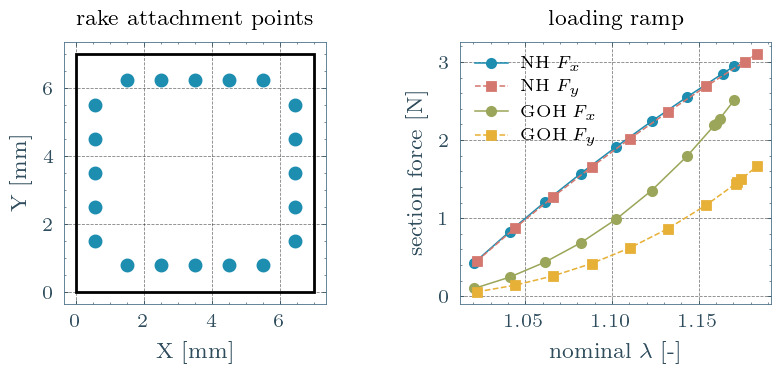

In [4]:
ref = results["nh"]["reference"]
meta = ref["meta"]
holes = ref["holes_n"] * ref["L"]

print(f"sample {meta['L']} x {meta['L']} mm, thickness {meta['H']} mm, "
      f"rake radius {meta['rake_radius']} mm")
print(f"rake inset: {meta['rake_inset']}")
print(f"frames used: {len(ref['states'])} of the ramp")

fig, ax = plt.subplots(1, 2, figsize=(page_width, page_width * 0.36), dpi=200,
                       gridspec_kw={"wspace": 0.35})
ax[0].add_patch(plt.Rectangle((0, 0), meta["L"], meta["L"], fill=False, lw=1.0))
ax[0].plot(holes[:, 0], holes[:, 1], "o", ms=4)
ax[0].set(aspect="equal", title="rake attachment points",
          xlabel="X [mm]", ylabel="Y [mm]")
ax[0].tick_params(labelsize=7)

for law, r in results.items():
    f = r["reference"]["force"]
    ax[1].plot(r["reference"]["states"][:, 0], f[:, 0], "o-", ms=3, label=f"{law.upper()} $F_x$")
    ax[1].plot(r["reference"]["states"][:, 1], f[:, 1], "s--", ms=3, label=f"{law.upper()} $F_y$")
ax[1].set(xlabel=r"nominal $\lambda$ [-]", ylabel="section force [N]", title="loading ramp")
ax[1].legend(fontsize=6, frameon=False)
ax[1].tick_params(labelsize=7)
plt.show()

## 3. Identified parameters

In [5]:
tables = {}
for law, r in results.items():
    df = parameter_table(r)
    tables[law] = df
    print(f"===== {law.upper()}  (MPE = {df.attrs['MPE [%]']:.2f} %) =====")
    print(df.round(5).to_string())
    display(df.round(5))

===== NH  (MPE = 8.40 %) =====
  parameter  ground truth  identified  rel. error [%]
0       C10          0.25     0.22899         8.40205


,parameter,ground truth,identified,rel. error [%]
0,C10,0.25,0.22899,8.40205


===== GOH  (MPE = 78.37 %) =====
   parameter  ground truth  identified  rel. error [%]
0        C10         0.013     0.02712       108.59828
1         k1         1.100     1.92187        74.71510
2         k2         3.700     0.01537        99.58457
3      kappa         0.240     0.29219        21.74429
4  alpha_deg        29.983     3.84073        87.19030


,parameter,ground truth,identified,rel. error [%]
0,C10,0.013,0.02712,108.59828
1,k1,1.100,1.92187,74.71510
2,k2,3.700,0.01537,99.58457
3,kappa,0.240,0.29219,21.74429
4,alpha_deg,29.983,3.84073,87.19030


The GOH result here is **not** usable — see `README_rakes_biaxial.md` for why the singleequibiaxial ramp is the limiting factor.

## 4. Parameter evolution and loss history

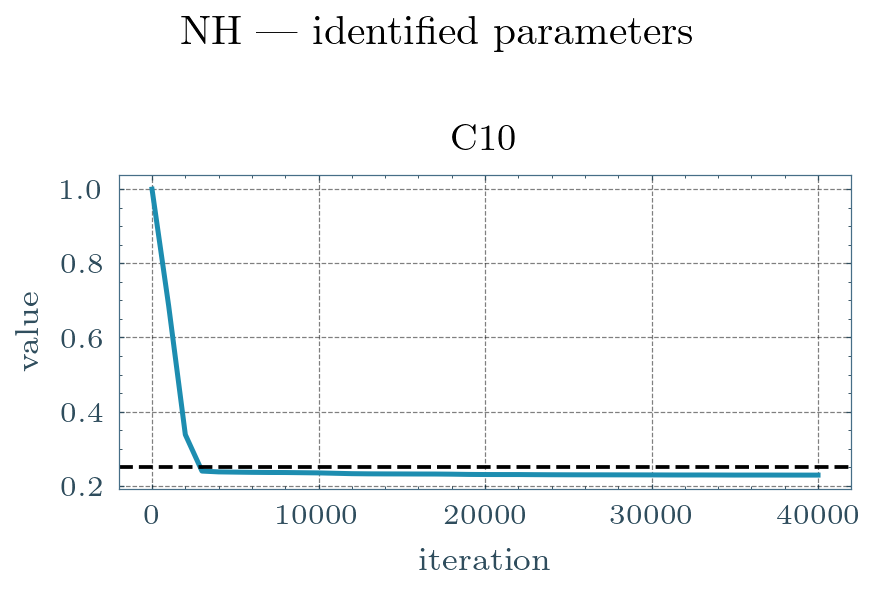

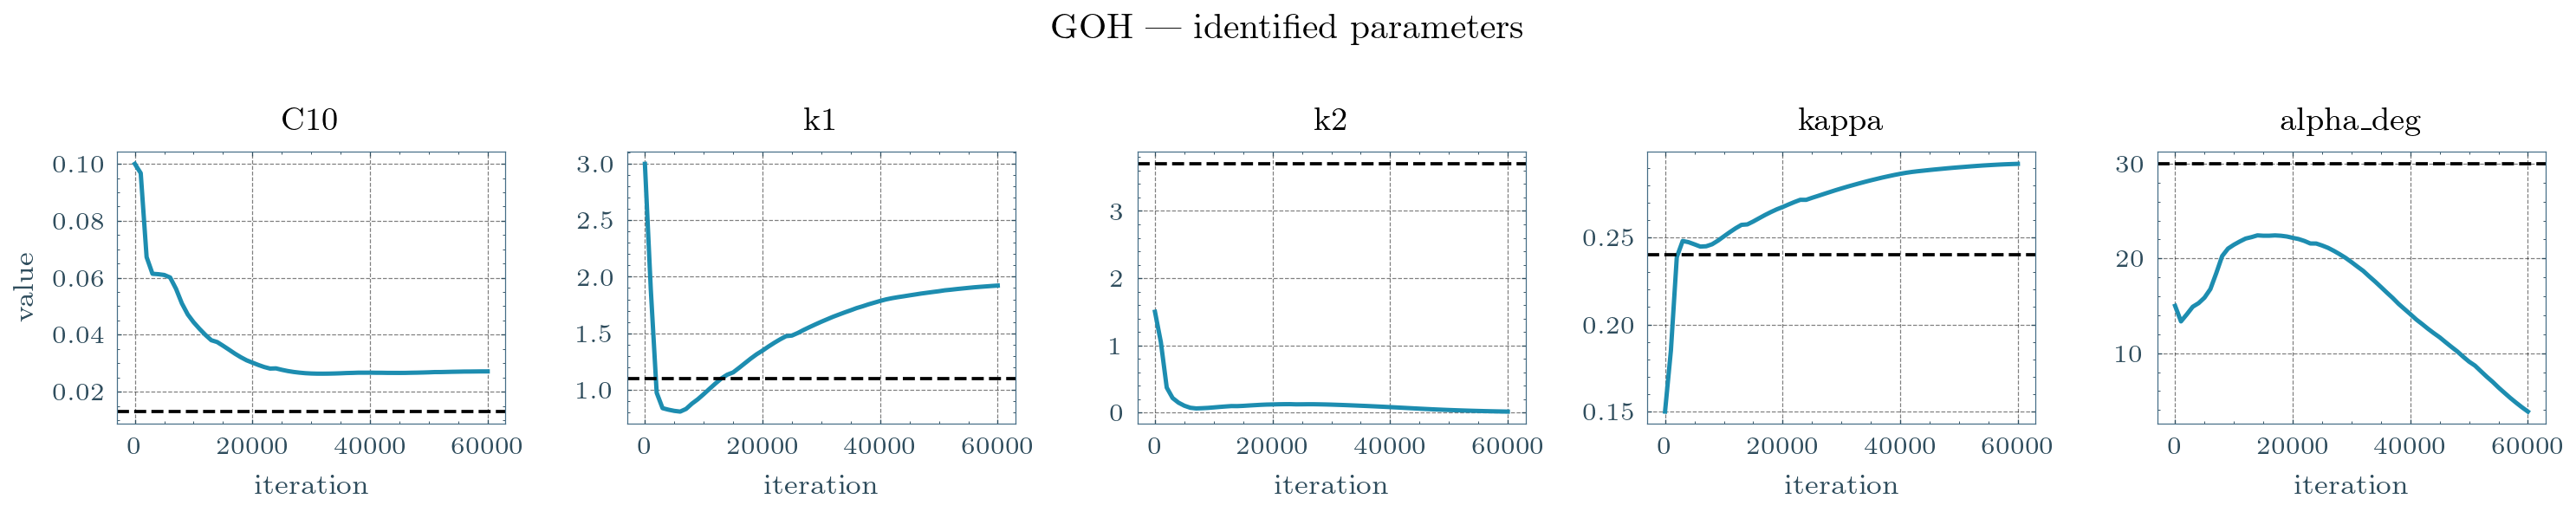

In [6]:
for law, r in results.items():
    n_param = len(r["external_vars"])
    fig, ax = plt.subplots(1, n_param, figsize=(max(n_param*2, 3), 2), dpi=300)
    ax = np.atleast_1d(ax)
    fig, ax = plot_parameter_evolution(r, fig=fig, ax=ax, title=f"{law.upper()} — identified parameters")
    fig.tight_layout(rect=(0, 0, 1, 0.95))
    if save_fig:
        fig.savefig(IMAGE_DIR / f"ideal_{law}_parameters.png", bbox_inches="tight", dpi=300)
    plt.show()

## 5. Displacement field: network vs Abaqus

The heterogeneity of this field is what makes the rake test more informative than theidealised one, so the comparison is worth looking at directly.

Restoring model from saved parameters...
Set the default automatic differentiation to forward mode.
[biaxial_rakes] law=nh frames=9 P_scale 0.0357..0.2463 MPa  u_scale 0.00943..0.07743 (u/L)
[biaxial_rakes] collocation 70x70, 132 points masked inside rake holes
[biaxial_rakes] displacement data 40x40x9, 49 grid points dropped (holes/NaN)
[biaxial_rakes] section forces: 5 cuts per direction, 40 quadrature points
Compiling model...
'compile' took 5.134552 s

Training model...

Step      Train loss                                                                                              Test loss                                                                                               Test metric
0         [5.81e-08, 4.46e-08, 1.18e-04, 3.45e-07, 1.64e-07, 1.43e-04, 4.35e-02, 4.71e-02, 1.00e+01, 1.00e+01]    [5.81e-08, 4.46e-08, 1.18e-04, 3.45e-07, 1.64e-07, 1.43e-04, 4.35e-02, 4.71e-02, 1.00e+01, 1.00e+01]    []  

Best model at step 0:
  train loss: 2.01e+01
  test loss: 2.01e+01

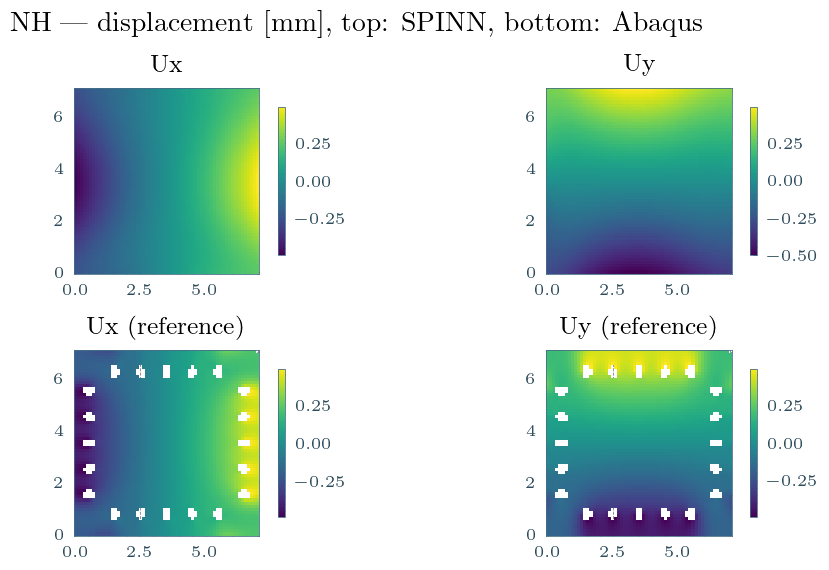

  NH Ux: NRMSE 5.367%
  NH Uy: NRMSE 7.904%
Restoring model from saved parameters...
Set the default automatic differentiation to forward mode.
[biaxial_rakes] law=goh frames=11 P_scale 0.0080..0.1995 MPa  u_scale 0.01025..0.07936 (u/L)
[biaxial_rakes] collocation 70x70, 132 points masked inside rake holes
[biaxial_rakes] displacement data 40x40x11, 49 grid points dropped (holes/NaN)
[biaxial_rakes] section forces: 5 cuts per direction, 40 quadrature points
Compiling model...
'compile' took 1.116688 s

Training model...

Step      Train loss                                                                                              Test loss                                                                                               Test metric
0         [6.82e-08, 5.24e-08, 3.27e-08, 4.18e-08, 3.19e-09, 8.66e-08, 5.22e-02, 7.62e-02, 1.00e+01, 1.00e+01]    [6.82e-08, 5.24e-08, 3.27e-08, 4.18e-08, 3.19e-09, 8.66e-08, 5.22e-02, 7.62e-02, 1.00e+01, 1.00e+01]    []  

Best model at step 

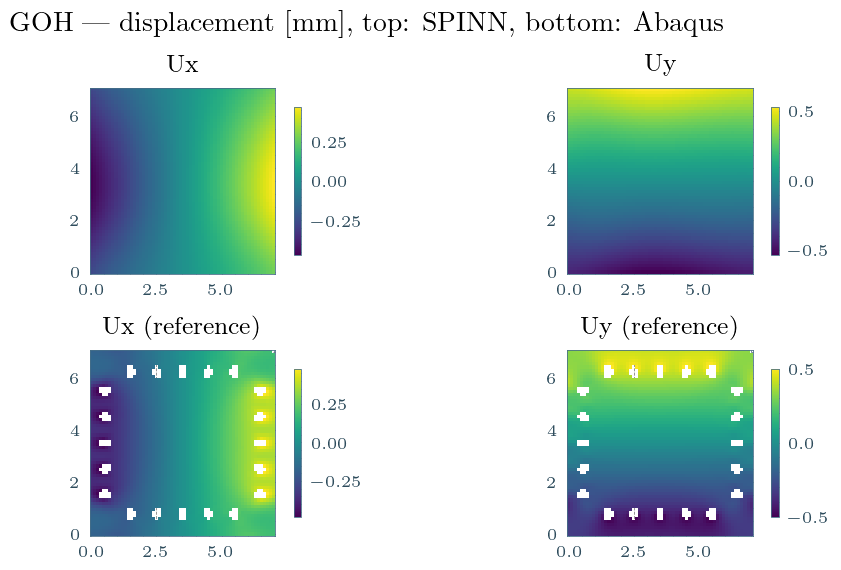

  GOH Ux: NRMSE 7.450%
  GOH Uy: NRMSE 6.873%


In [7]:
SHOW_FIELDS = True

if SHOW_FIELDS:
    for law, run_name in RUNS.items():
        r = results[law] if MODE == "run" else br.load_run(run_name, restore_model=True)
        last = len(r["reference"]["states"]) - 1
        X, Y, fields = br.predict_state(r, last, n_grid=60)
        Xr, Yr, ref_fields = br.reference_state(r, last)

        # put the reference on the prediction grid for a like-for-like picture
        from scipy.interpolate import RegularGridInterpolator
        ref_on = {}
        for comp in ("Ux", "Uy"):
            gi = RegularGridInterpolator((Xr[:, 0], Yr[0, :]), ref_fields[comp],
                                         bounds_error=False)
            ref_on[comp] = gi((X, Y))

        fig, ax = plot_fields(X, Y, fields, ["Ux", "Uy"],
                              suptitle=f"{law.upper()} — displacement [mm], "
                                       f"top: SPINN, bottom: Abaqus",
                              ref=ref_on)
        if save_fig:
            fig.savefig(IMAGE_DIR / f"rakes_{law}_displacement.png",
                        bbox_inches="tight", dpi=300)
        plt.show()

        for comp in ("Ux", "Uy"):
            m = ~np.isnan(ref_on[comp])
            nrmse = np.sqrt(np.mean((fields[comp][m] - ref_on[comp][m]) ** 2)) \
                    / np.max(np.abs(ref_on[comp][m]))
            print(f"  {law.upper()} {comp}: NRMSE {nrmse:.3%}")

## 6. Section forces: network vs Abaqus

Restoring model from saved parameters...
Set the default automatic differentiation to forward mode.
[biaxial_rakes] law=nh frames=9 P_scale 0.0357..0.2463 MPa  u_scale 0.00943..0.07743 (u/L)
[biaxial_rakes] collocation 70x70, 132 points masked inside rake holes
[biaxial_rakes] displacement data 40x40x9, 49 grid points dropped (holes/NaN)
[biaxial_rakes] section forces: 5 cuts per direction, 40 quadrature points
Compiling model...
'compile' took 0.218520 s

Training model...

Step      Train loss                                                                                              Test loss                                                                                               Test metric
0         [5.81e-08, 4.46e-08, 1.18e-04, 3.45e-07, 1.64e-07, 1.43e-04, 4.35e-02, 4.71e-02, 1.00e+01, 1.00e+01]    [5.81e-08, 4.46e-08, 1.18e-04, 3.45e-07, 1.64e-07, 1.43e-04, 4.35e-02, 4.71e-02, 1.00e+01, 1.00e+01]    []  

Best model at step 0:
  train loss: 2.01e+01
  test loss: 2.01e+01

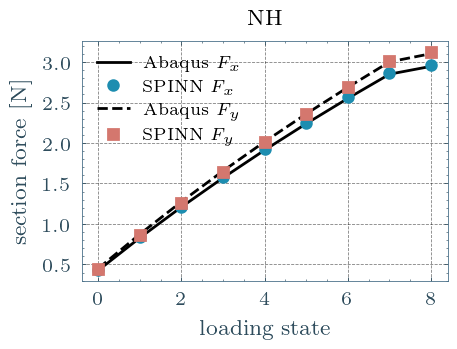

Restoring model from saved parameters...
Set the default automatic differentiation to forward mode.
[biaxial_rakes] law=goh frames=11 P_scale 0.0080..0.1995 MPa  u_scale 0.01025..0.07936 (u/L)
[biaxial_rakes] collocation 70x70, 132 points masked inside rake holes
[biaxial_rakes] displacement data 40x40x11, 49 grid points dropped (holes/NaN)
[biaxial_rakes] section forces: 5 cuts per direction, 40 quadrature points
Compiling model...
'compile' took 0.142762 s

Training model...

Step      Train loss                                                                                              Test loss                                                                                               Test metric
0         [6.82e-08, 5.24e-08, 3.27e-08, 4.18e-08, 3.19e-09, 8.66e-08, 5.22e-02, 7.62e-02, 1.00e+01, 1.00e+01]    [6.82e-08, 5.24e-08, 3.27e-08, 4.18e-08, 3.19e-09, 8.66e-08, 5.22e-02, 7.62e-02, 1.00e+01, 1.00e+01]    []  

Best model at step 0:
  train loss: 2.01e+01
  test loss: 2.01e

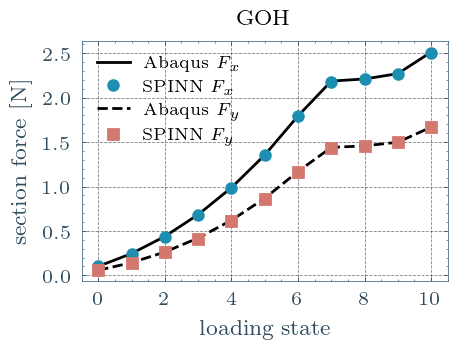

In [8]:
for law, run_name in RUNS.items():
    r = results[law] if MODE == "run" else br.load_run(run_name, restore_model=True)
    pred = br.predicted_forces(r)
    meas = r["reference"]["force"]
    nrmse = np.sqrt(np.mean((pred - meas) ** 2, axis=0)) / np.mean(np.abs(meas), axis=0)
    print(f"{law.upper()}: section force NRMSE  Fx {nrmse[0]:.3%}   Fy {nrmse[1]:.3%}")

    fig, ax = plt.subplots(figsize=(page_width * 0.5, page_width * 0.33), dpi=200)
    idx = np.arange(len(meas))
    ax.plot(idx, meas[:, 0], "k-", lw=1.0, label="Abaqus $F_x$")
    ax.plot(idx, pred[:, 0], "o", ms=3.5, label="SPINN $F_x$")
    ax.plot(idx, meas[:, 1], "k--", lw=1.0, label="Abaqus $F_y$")
    ax.plot(idx, pred[:, 1], "s", ms=3.5, label="SPINN $F_y$")
    ax.set(xlabel="loading state", ylabel="section force [N]", title=law.upper())
    ax.legend(fontsize=6, frameon=False)
    ax.tick_params(labelsize=7)
    plt.show()